In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## Preparing Required Libraries

In [2]:
# 1. Install/import packages
!pip -q install xgboost shap scikit-learn pandas numpy matplotlib seaborn joblib

import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
CSV_PATH = "data/raw/content_refresh_anonymized.csv"
OUTPUT_DIR = Path("outputs_content_decline")
OUTPUT_DIR.mkdir(exist_ok=True)


## Preparing the Dataset

In [3]:
# 2. Load dataset
df = pd.read_csv(CSV_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())
print(df.columns.tolist())


Rows: 30,000
Columns: 44


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


is_declining_label
1    16262
0    13738
Name: count, dtype: int64
Decline rate: 0.542


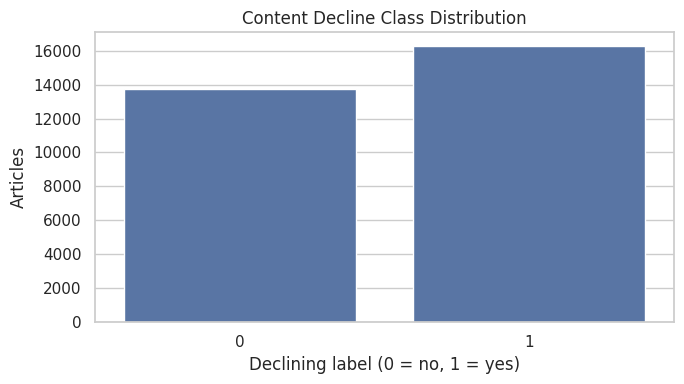

In [4]:
# 3. Create/inspect decline target
if "is_declining_label" not in df.columns:
    if "trend_direction" not in df.columns:
        raise ValueError("Need 'is_declining_label' or 'trend_direction'.")
    df["is_declining_label"] = (
        df["trend_direction"].astype("string").str.lower().eq("down").astype(int)
    )

TARGET = "is_declining_label"

print(df[TARGET].value_counts(dropna=False))
print(f"Decline rate: {df[TARGET].mean():.3f}")

plt.figure(figsize=(7,4))
sns.countplot(data=df, x=TARGET)
plt.title("Content Decline Class Distribution")
plt.xlabel("Declining label (0 = no, 1 = yes)")
plt.ylabel("Articles")
plt.tight_layout()
plt.show()


## Features

In [5]:
# 4. Define model features
NUMERIC_FEATURES = [
    "search_volume", "competition", "cpc",
    "word_count", "char_count",
    "impressions_prev_30d", "clicks_prev_30d",
    "sessions_prev_30d", "content_age_days",
    "days_since_last_update", "avg_position",
]

CATEGORICAL_FEATURES = [
    "competition_level", "content_type", "main_intent",
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

missing = [c for c in FEATURES + [TARGET] if c not in df.columns]
if missing:
    raise ValueError("Missing columns:\n" + "\n".join(f"- {c}" for c in missing))

data = df[FEATURES + [TARGET]].dropna(subset=[TARGET]).copy()
data[TARGET] = data[TARGET].astype(int)

if not data[TARGET].isin([0,1]).all():
    raise ValueError("Target must contain only 0/1.")

X = data[FEATURES].copy()
y = data[TARGET].copy()

print(f"Model rows: {len(data):,}")
display(data[FEATURES].isna().sum().sort_values(ascending=False).to_frame("missing"))


Model rows: 30,000


,missing
char_count,7699
word_count,7699
competition_level,2610
competition,2468
cpc,2468
search_volume,2468
main_intent,2374
impressions_prev_30d,0
clicks_prev_30d,0
sessions_prev_30d,0


## Splitting Dataset


In [6]:
# 5. Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {len(X_train):,}")
print(f"Test : {len(X_test):,}")
print(f"Train decline rate: {y_train.mean():.3f}")
print(f"Test decline rate : {y_test.mean():.3f}")


Train: 24,000
Test : 6,000
Train decline rate: 0.542
Test decline rate : 0.542


## Training the Model

In [7]:
# 6. Train XGBoost decline-risk classifier
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipe, NUMERIC_FEATURES),
    ("categorical", categorical_pipe, CATEGORICAL_FEATURES),
])

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count if positive_count else 1.0

classifier = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", classifier),
])

pipeline.fit(X_train, y_train)
print("Training completed.")


Training completed.


## Evaluate Classifier

In [9]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.50).astype(int)

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC : {pr_auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(cm, index=["Actual 0","Actual 1"], columns=["Predicted 0","Predicted 1"]))


ROC-AUC: 0.8098
PR-AUC : 0.8200

Classification report:
              precision    recall  f1-score   support

           0     0.7234    0.6692    0.6953      2748
           1     0.7371    0.7838    0.7598      3252

    accuracy                         0.7313      6000
   macro avg     0.7303    0.7265    0.7275      6000
weighted avg     0.7309    0.7313    0.7302      6000



,Predicted 0,Predicted 1
Actual 0,1839,909
Actual 1,703,2549


## ROC and Precision-Recall Curves

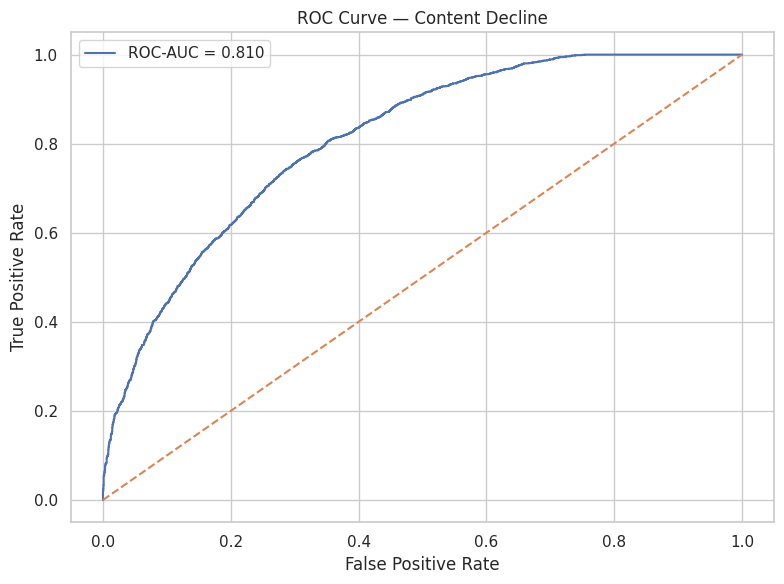

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Content Decline")
plt.legend()
plt.tight_layout()
plt.show()




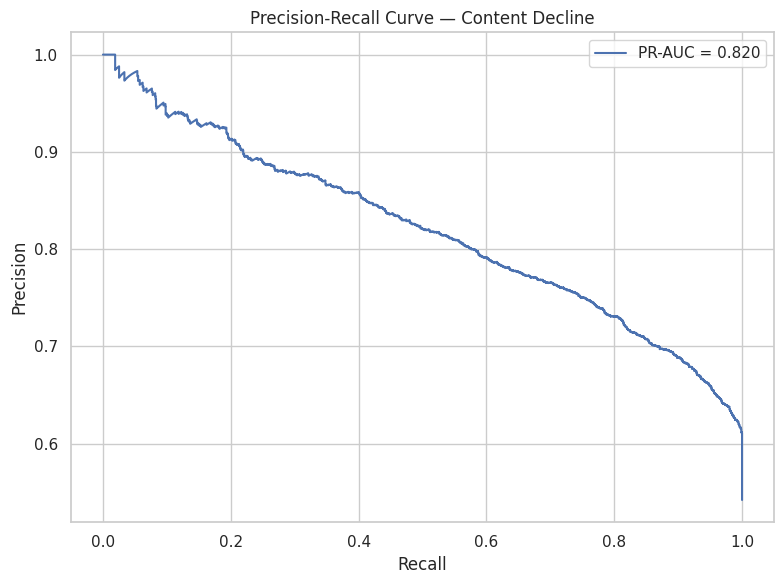

In [12]:
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Content Decline")
plt.legend()
plt.tight_layout()
plt.show()

## Native XGBOOST Importance

In [15]:
fitted_preprocessor = pipeline.named_steps["preprocessor"]
fitted_model = pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
importance = fitted_model.feature_importances_

native_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importance})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(native_importance.head(25))
native_importance.to_csv(OUTPUT_DIR / "xgboost_feature_importance.csv", index=False)



,feature,importance
0,numeric__impressions_prev_30d,0.180895
1,categorical__content_type_comparison article,0.082981
2,numeric__content_age_days,0.068847
3,categorical__content_type_keyword article,0.063351
4,numeric__days_since_last_update,0.061608
5,numeric__clicks_prev_30d,0.060622
6,numeric__avg_position,0.055612
7,numeric__sessions_prev_30d,0.041643
8,numeric__char_count,0.041638
9,numeric__word_count,0.038813


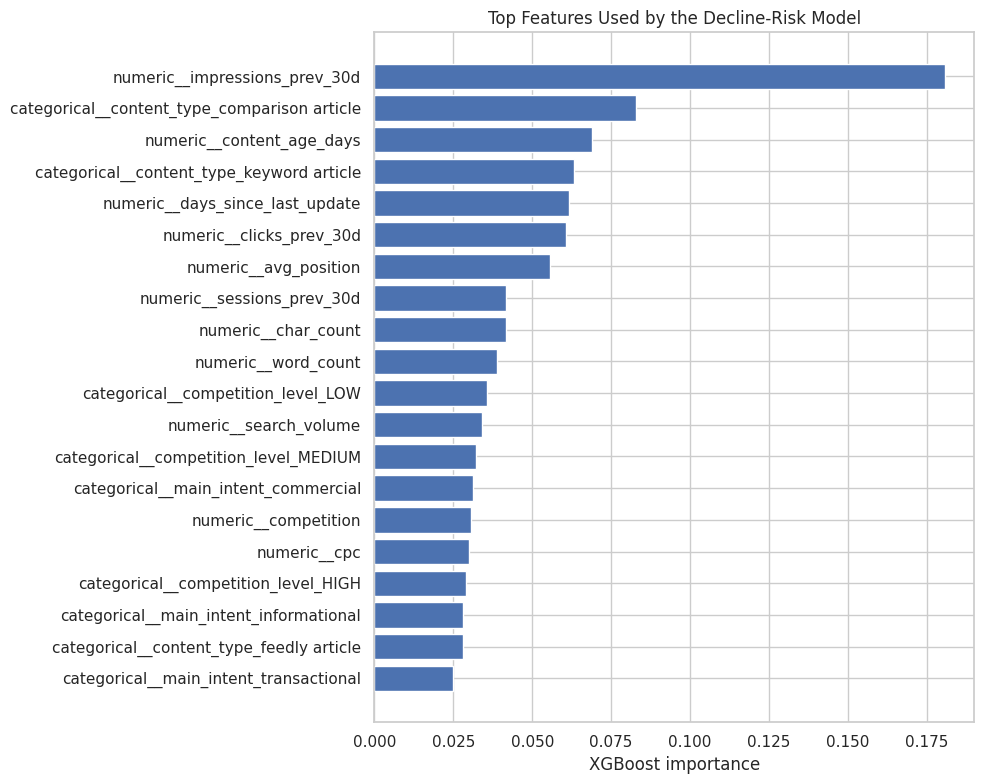

In [16]:
top = native_importance.head(20).sort_values("importance")
plt.figure(figsize=(10,8))
plt.barh(top["feature"], top["importance"])
plt.xlabel("XGBoost importance")
plt.title("Top Features Used by the Decline-Risk Model")
plt.tight_layout()
plt.show()

# Permutation importance on the raw held-out features


,feature,importance_mean,importance_std
0,impressions_prev_30d,0.241378,0.003328
1,content_age_days,0.054973,0.002092
2,avg_position,0.051935,0.003631
3,clicks_prev_30d,0.047833,0.001700
4,days_since_last_update,0.026834,0.001215
5,char_count,0.014374,0.001387
6,word_count,0.010430,0.000777
7,sessions_prev_30d,0.008276,0.001141
8,content_type,0.004405,0.000439
9,search_volume,0.003201,0.000562


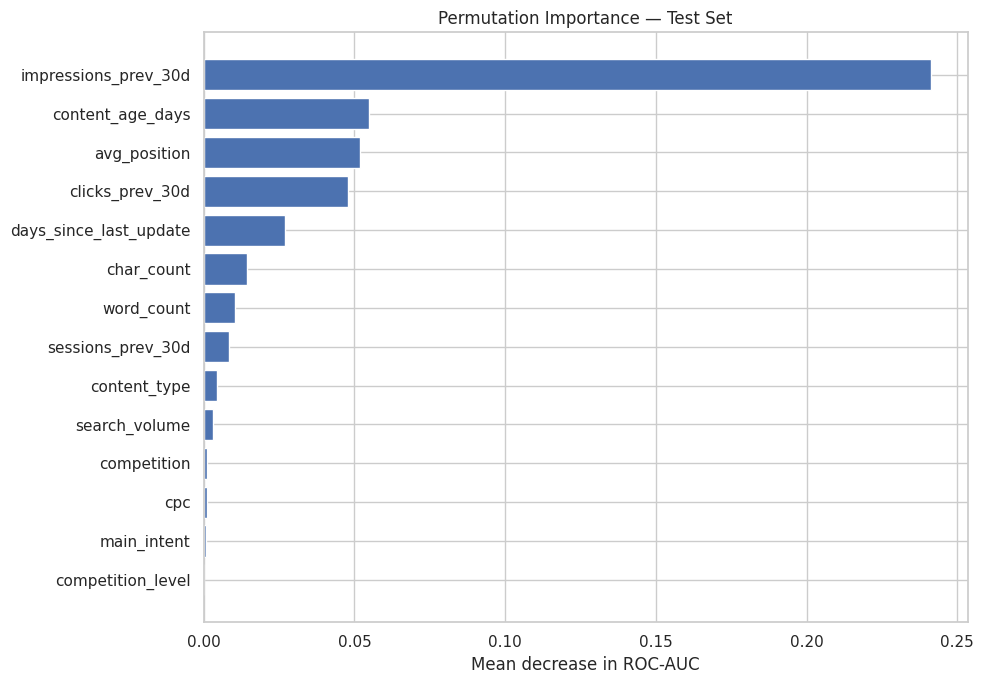

In [17]:
perm = permutation_importance(
    pipeline,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_table = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(perm_table)
perm_table.to_csv(OUTPUT_DIR / "permutation_importance.csv", index=False)

top_perm = perm_table.head(15).sort_values("importance_mean")
plt.figure(figsize=(10,7))
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.xlabel("Mean decrease in ROC-AUC")
plt.title("Permutation Importance — Test Set")
plt.tight_layout()
plt.show()


## SHAP Global Explanation

In [18]:
# SHAP values on the model's transformed feature space
#
# XGBoost sees one-hot encoded categorical variables, so this first SHAP calculation
# gives us the model's exact per-transformed-feature contributions.

X_test_transformed = fitted_preprocessor.transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_shap = X_test_transformed.toarray()
else:
    X_test_shap = X_test_transformed

explainer = shap.TreeExplainer(fitted_model)
shap_values = explainer.shap_values(X_test_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[-1]

shap_values = np.asarray(shap_values)

print("Transformed SHAP shape:", shap_values.shape)
print("Transformed feature count:", len(feature_names))


SHAP shape: (6000, 21)
Feature count: 21


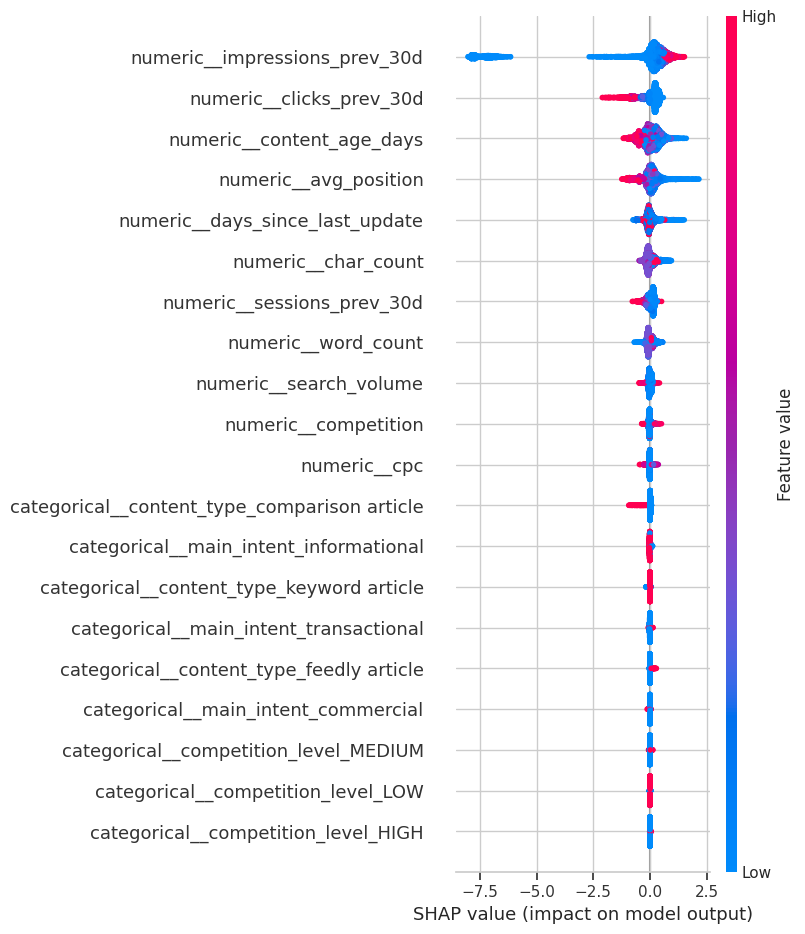

In [21]:
# SHAP global summary at the transformed-feature level
#
# This plot is technically exact, but categorical variables appear as separate
# one-hot columns. We keep it as a diagnostic view.

shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_names,
    show=True
)


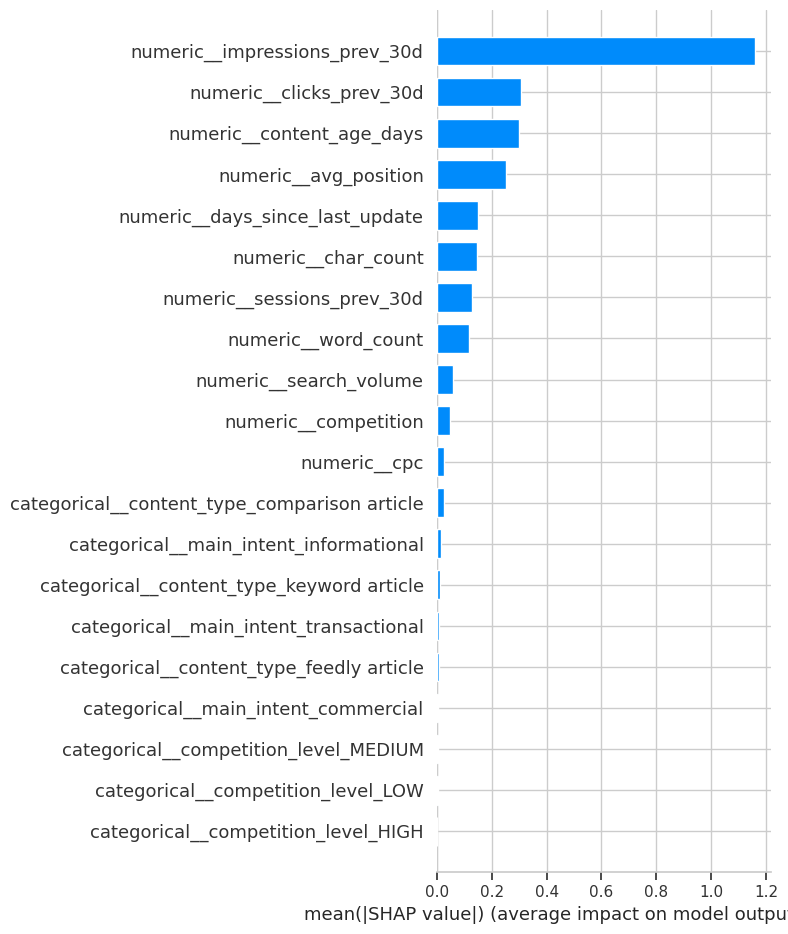

In [22]:
# SHAP global bar plot at the transformed-feature level
shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)


## SHAP Aggregated to Original FlyRank Features

One-hot encoding creates multiple model features from a single business feature. For example, `content_type` may become `content_type_BLOG`, `content_type_GUIDE`, etc.

For FlyRank interpretation, we aggregate those SHAP contributions back to the original feature. This lets us answer questions such as **"How much did `content_type` contribute to this prediction?"** rather than exposing individual one-hot columns.

For each original feature, the local SHAP contribution is the sum of its transformed columns. Global importance is then computed as the mean absolute aggregated SHAP value across the test set.


In [ ]:
# Build a mapping from transformed columns back to the original feature names.

def build_shap_feature_mapping(transformed_names, numeric_features, categorical_features):
    mapping = {}

    for transformed_name in transformed_names:
        matched = False

        # Numeric transformer normally produces names such as:
        # numeric__search_volume
        for raw_feature in numeric_features:
            if transformed_name == f"numeric__{raw_feature}":
                mapping[transformed_name] = raw_feature
                matched = True
                break

        if matched:
            continue

        # Categorical transformer normally produces names such as:
        # categorical__content_type_BLOG
        # Match against the original feature prefix rather than splitting on "_",
        # because original feature names can themselves contain underscores.
        for raw_feature in categorical_features:
            prefix = f"categorical__{raw_feature}_"
            if transformed_name.startswith(prefix):
                mapping[transformed_name] = raw_feature
                matched = True
                break

        if not matched:
            # Keep an unexpected transformed feature visible rather than silently
            # dropping it from the explainability output.
            mapping[transformed_name] = transformed_name

    return mapping


shap_feature_mapping = build_shap_feature_mapping(
    feature_names,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
)

mapping_table = pd.DataFrame({
    "transformed_feature": feature_names,
    "original_feature": [shap_feature_mapping[name] for name in feature_names],
})

display(mapping_table.head(30))
mapping_table.to_csv(
    OUTPUT_DIR / "shap_transformed_to_original_feature_mapping.csv",
    index=False
)

print("Original features represented:", mapping_table["original_feature"].nunique())


In [ ]:
# Aggregate transformed SHAP values to the original FlyRank feature level.

def aggregate_shap_values(shap_matrix, transformed_names, feature_mapping, original_features):
    transformed_df = pd.DataFrame(
        shap_matrix,
        columns=transformed_names,
    )

    aggregated = pd.DataFrame(index=transformed_df.index)

    for original_feature in original_features:
        source_columns = [
            transformed_name
            for transformed_name in transformed_names
            if feature_mapping[transformed_name] == original_feature
        ]

        if source_columns:
            aggregated[original_feature] = transformed_df[source_columns].sum(axis=1)
        else:
            aggregated[original_feature] = 0.0

    return aggregated


shap_values_original = aggregate_shap_values(
    shap_values,
    feature_names,
    shap_feature_mapping,
    FEATURES,
)

print("Aggregated SHAP shape:", shap_values_original.shape)
display(shap_values_original.head())


In [ ]:
# Global SHAP importance at the original business-feature level.

global_shap_importance = pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": shap_values_original.abs().mean(axis=0).values,
    "mean_shap": shap_values_original.mean(axis=0).values,
})

global_shap_importance["abs_mean_shap"] = global_shap_importance["mean_shap"].abs()
global_shap_importance = (
    global_shap_importance
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(global_shap_importance)

global_shap_importance.to_csv(
    OUTPUT_DIR / "shap_global_importance_original_features.csv",
    index=False
)

plt.figure(figsize=(10, 7))
plot_df = global_shap_importance.head(15).sort_values("mean_abs_shap")
plt.barh(plot_df["feature"], plot_df["mean_abs_shap"])
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Original feature")
plt.title("Global SHAP Importance — Original FlyRank Features")
plt.tight_layout()
plt.show()


### Why this aggregation matters

For numeric variables, the mapping is one transformed column → one original feature. For categorical variables, several one-hot columns → one original feature, and their SHAP contributions are summed for each article.

Therefore a categorical feature such as `content_type` receives one article-level SHAP contribution regardless of which category was active. This makes the explanation much easier to use in a FlyRank content-refresh workflow.


# Partial dependence for key numeric features


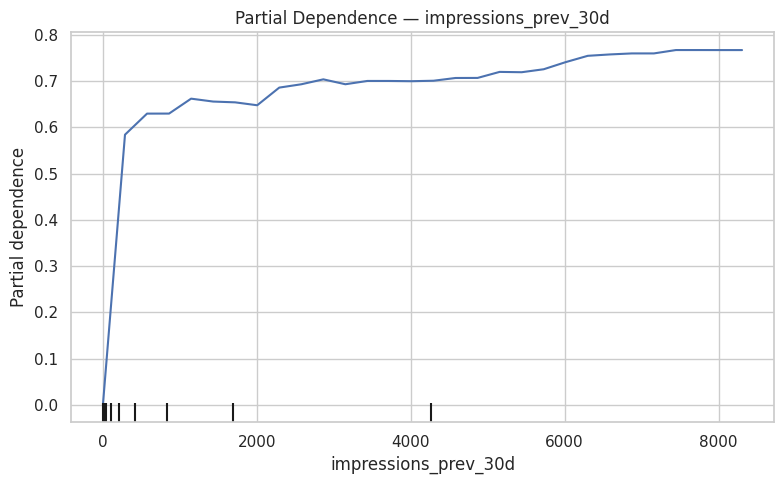

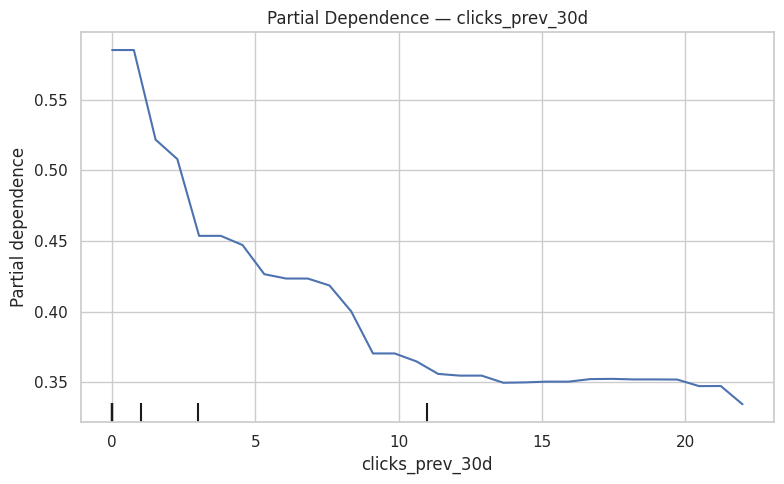

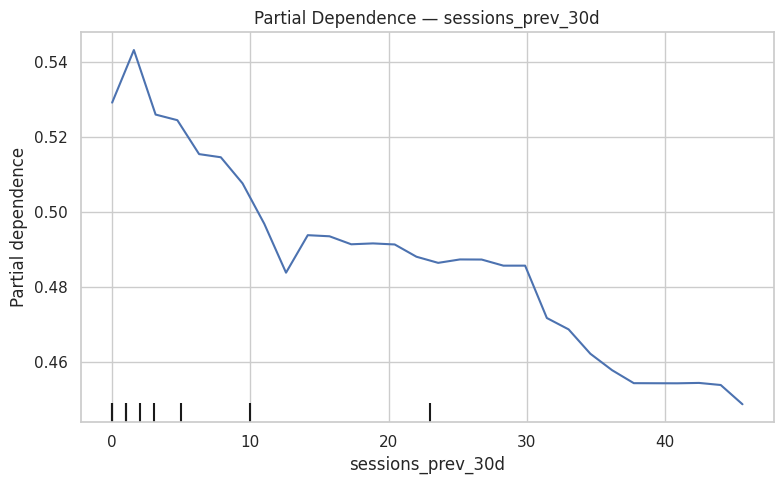

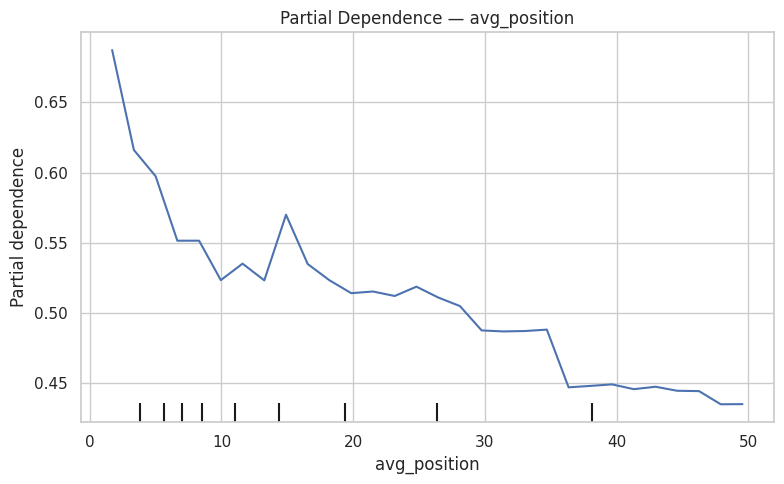

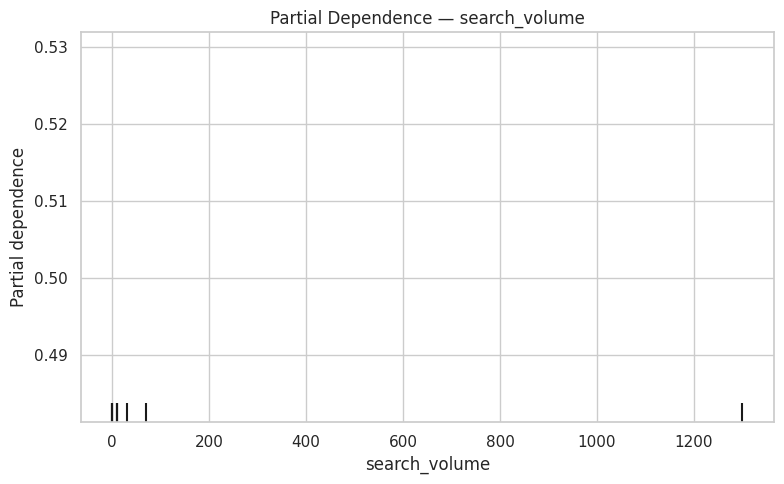

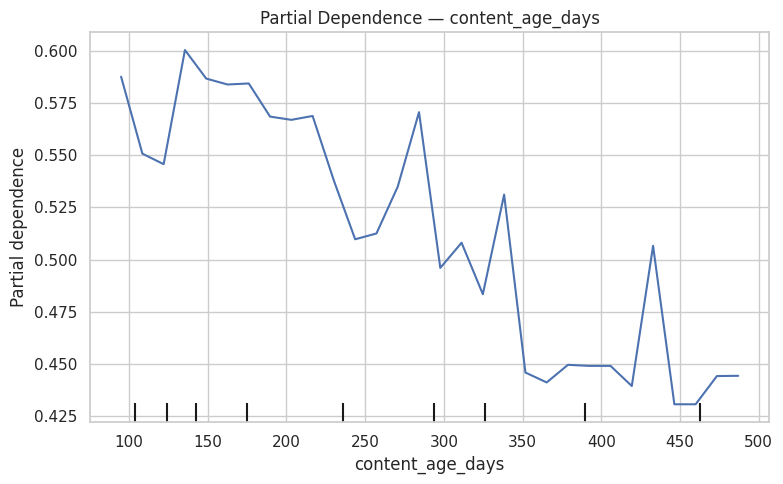

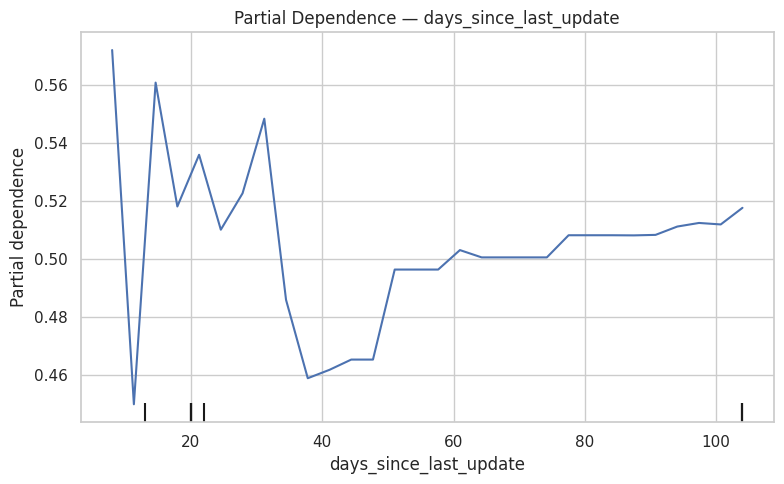

In [23]:
pdp_features = [
    c for c in [
        "impressions_prev_30d",
        "clicks_prev_30d",
        "sessions_prev_30d",
        "avg_position",
        "search_volume",
        "content_age_days",
        "days_since_last_update",
    ] if c in X_test.columns
]

for feature in pdp_features:
    fig, ax = plt.subplots(figsize=(8,5))
    PartialDependenceDisplay.from_estimator(
        pipeline,
        X_test,
        [feature],
        response_method="predict_proba",
        target=1,
        ax=ax,
        grid_resolution=30,
    )
    ax.set_title(f"Partial Dependence — {feature}")
    plt.tight_layout()
    plt.show()


## Risk Table

In [24]:
risk_table = X_test.copy()
risk_table["actual_decline"] = y_test.to_numpy()
risk_table["decline_probability"] = y_proba
risk_table["predicted_decline"] = (y_proba >= 0.50).astype(int)
risk_table = risk_table.sort_values("decline_probability", ascending=False)

display(risk_table.head(20))
risk_table.to_csv(OUTPUT_DIR / "content_decline_risk_scores.csv", index=False)


,search_volume,competition,cpc,word_count,char_count,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,days_since_last_update,avg_position,competition_level,content_type,main_intent,actual_decline,decline_probability,predicted_decline
3211,30.0,0.00,0.00,1604.0,10492.0,497,0,2,230,104,1.3,LOW,keyword article,informational,1,0.987324,1
3448,30.0,0.35,0.34,1410.0,9171.0,660,0,1,139,104,2.8,MEDIUM,keyword article,transactional,1,0.982441,1
9456,10.0,0.21,0.00,2947.0,20773.0,2,0,1,96,8,8.2,LOW,keyword article,commercial,1,0.980593,1
28243,NaN,NaN,NaN,4146.0,30889.0,13,0,0,92,8,7.3,NaN,feedly article,NaN,1,0.979208,1
2006,10.0,0.24,0.00,3033.0,20698.0,30,0,3,96,8,8.8,LOW,keyword article,informational,1,0.978609,1
24991,10.0,0.36,0.92,2947.0,20027.0,23,0,1,96,8,7.6,MEDIUM,keyword article,commercial,1,0.975211,1
15939,10.0,0.79,0.00,3224.0,22100.0,7,0,1,96,8,7.8,HIGH,keyword article,commercial,1,0.974159,1
11007,10.0,0.00,0.00,3138.0,20823.0,7,0,1,96,8,21.7,LOW,keyword article,commercial,1,0.972245,1
12444,0.0,0.00,0.00,4471.0,30867.0,10355,10,9,132,20,33.9,LOW,keyword article,informational,1,0.971965,1
16634,0.0,0.00,0.00,4153.0,27943.0,9761,0,3,141,20,31.5,LOW,keyword article,informational,1,0.971748,1


## Article-Level SHAP Explanation

The explanation below now aggregates one-hot SHAP values back to the original FlyRank feature names. This makes the local explanation directly interpretable at the business-feature level.

**Positive SHAP** → pushes the prediction toward decline.  
**Negative SHAP** → pushes the prediction away from decline.


In [26]:
def explain_article(row_position, top_n=10):
    """
    Explain one article at the ORIGINAL FlyRank feature level.

    Positive SHAP values push the model toward decline.
    Negative SHAP values push the model away from decline.
    """
    if row_position < 0 or row_position >= len(X_test):
        raise IndexError("row_position is outside X_test.")

    row_raw = X_test.iloc[[row_position]]
    row_transformed = fitted_preprocessor.transform(row_raw)

    if hasattr(row_transformed, "toarray"):
        row_transformed = row_transformed.toarray()

    # Calculate local SHAP values on the transformed feature space.
    row_shap_transformed = explainer.shap_values(row_transformed)

    if isinstance(row_shap_transformed, list):
        row_shap_transformed = row_shap_transformed[-1]

    row_shap_transformed = np.asarray(row_shap_transformed).reshape(-1)

    # Aggregate one-hot contributions back to original features.
    row_shap_original = aggregate_shap_values(
        row_shap_transformed.reshape(1, -1),
        feature_names,
        shap_feature_mapping,
        FEATURES,
    ).iloc[0]

    probability = pipeline.predict_proba(row_raw)[0, 1]
    actual = int(y_test.iloc[row_position])

    explanation = pd.DataFrame({
        "feature": FEATURES,
        "feature_value": [
            row_raw.iloc[0][feature] for feature in FEATURES
        ],
        "shap_value": [
            row_shap_original[feature] for feature in FEATURES
        ],
    })

    explanation["direction"] = np.where(
        explanation["shap_value"] > 0,
        "increases decline risk",
        "decreases decline risk",
    )
    explanation["abs_shap"] = explanation["shap_value"].abs()
    explanation = explanation.sort_values(
        "abs_shap",
        ascending=False
    ).reset_index(drop=True)

    print("=" * 70)
    print("ARTICLE-LEVEL DECLINE EXPLANATION — ORIGINAL FEATURES")
    print("=" * 70)
    print(f"Test row             : {row_position}")
    print(f"Actual decline label : {actual}")
    print(f"Predicted risk       : {probability:.2%}")

    print("\nArticle features:")
    display(row_raw.T.rename(columns={row_raw.index[0]: "value"}))

    print("\nTop features increasing decline risk:")
    display(
        explanation[explanation["shap_value"] > 0]
        .head(top_n)[["feature", "feature_value", "shap_value", "direction"]]
    )

    print("\nTop features decreasing decline risk:")
    display(
        explanation[explanation["shap_value"] < 0]
        .head(top_n)[["feature", "feature_value", "shap_value", "direction"]]
    )

    # Aggregated SHAP waterfall-style bar chart.
    plot_df = explanation.head(top_n).sort_values("shap_value")

    plt.figure(figsize=(10, 7))
    plt.barh(plot_df["feature"], plot_df["shap_value"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("SHAP contribution")
    plt.ylabel("Original feature")
    plt.title(
        f"Why this article is predicted at {probability:.1%} decline risk"
    )
    plt.tight_layout()
    plt.show()

    return explanation


ARTICLE-LEVEL DECLINE EXPLANATION
Test row             : 5319
Actual decline label : 1
Predicted risk       : 98.73%

Article features:


,value
search_volume,30.0
competition,0.0
cpc,0.0
word_count,1604.0
char_count,10492.0
impressions_prev_30d,497
clicks_prev_30d,0
sessions_prev_30d,2
content_age_days,230
days_since_last_update,104



Top features increasing decline risk:


,feature,shap_value,direction
10,numeric__avg_position,2.035636,increases decline risk
5,numeric__impressions_prev_30d,0.734728,increases decline risk
6,numeric__clicks_prev_30d,0.463553,increases decline risk
3,numeric__word_count,0.378870,increases decline risk
4,numeric__char_count,0.324614,increases decline risk
7,numeric__sessions_prev_30d,0.281062,increases decline risk
8,numeric__content_age_days,0.097490,increases decline risk
9,numeric__days_since_last_update,0.038504,increases decline risk
14,categorical__content_type_comparison article,0.019091,increases decline risk
20,categorical__main_intent_transactional,0.010804,increases decline risk



Top features decreasing decline risk:


,feature,shap_value,direction
1,numeric__competition,-0.032910,decreases decline risk
0,numeric__search_volume,-0.005631,decreases decline risk
18,categorical__main_intent_informational,-0.001766,decreases decline risk
17,categorical__main_intent_commercial,-0.000892,decreases decline risk
12,categorical__competition_level_LOW,-0.000489,decreases decline risk
11,categorical__competition_level_HIGH,-0.000485,decreases decline risk


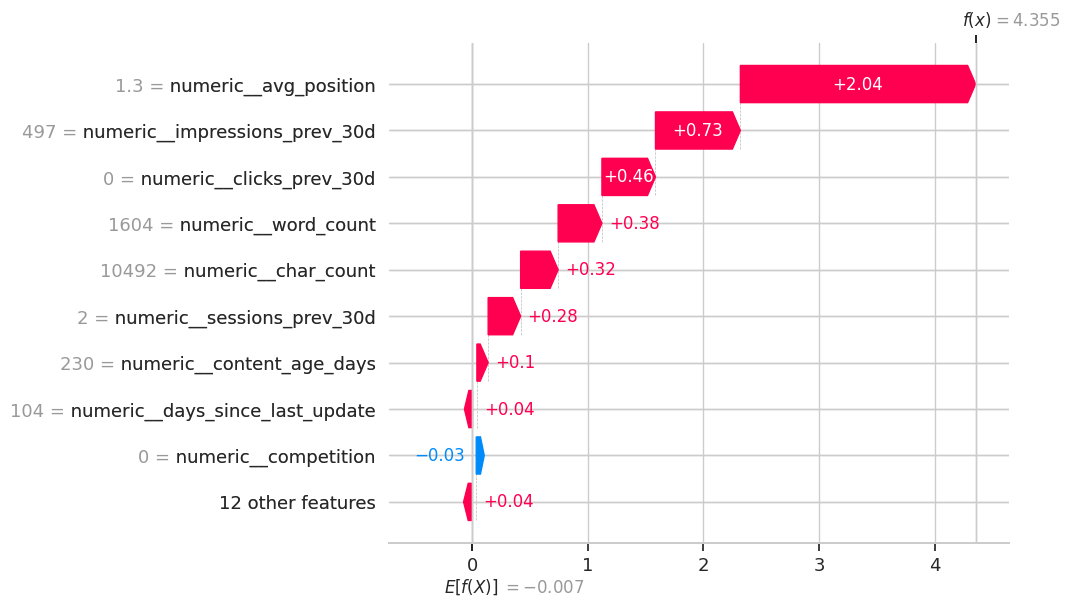

In [28]:
highest_risk_position = int(np.argmax(y_proba))
highest_risk_explanation = explain_article(
    highest_risk_position,
    top_n=10
)


## False Positive Inspection

ARTICLE-LEVEL DECLINE EXPLANATION
Test row             : 350
Actual decline label : 0
Predicted risk       : 94.28%

Article features:


,value
search_volume,10.0
competition,0.04
cpc,0.0
word_count,2462.0
char_count,15736.0
impressions_prev_30d,170
clicks_prev_30d,0
sessions_prev_30d,0
content_age_days,347
days_since_last_update,7



Top features increasing decline risk:


,feature,shap_value,direction
10,numeric__avg_position,1.692123,increases decline risk
9,numeric__days_since_last_update,0.491887,increases decline risk
6,numeric__clicks_prev_30d,0.395250,increases decline risk
5,numeric__impressions_prev_30d,0.238943,increases decline risk
7,numeric__sessions_prev_30d,0.178065,increases decline risk
4,numeric__char_count,0.127434,increases decline risk
1,numeric__competition,0.125329,increases decline risk
14,categorical__content_type_comparison article,0.016111,increases decline risk
17,categorical__main_intent_commercial,0.009534,increases decline risk
16,categorical__content_type_keyword article,0.009322,increases decline risk



Top features decreasing decline risk:


,feature,shap_value,direction
8,numeric__content_age_days,-0.414020,decreases decline risk
3,numeric__word_count,-0.048881,decreases decline risk
0,numeric__search_volume,-0.028258,decreases decline risk
15,categorical__content_type_feedly article,-0.001562,decreases decline risk
12,categorical__competition_level_LOW,-0.000505,decreases decline risk
11,categorical__competition_level_HIGH,-0.000343,decreases decline risk


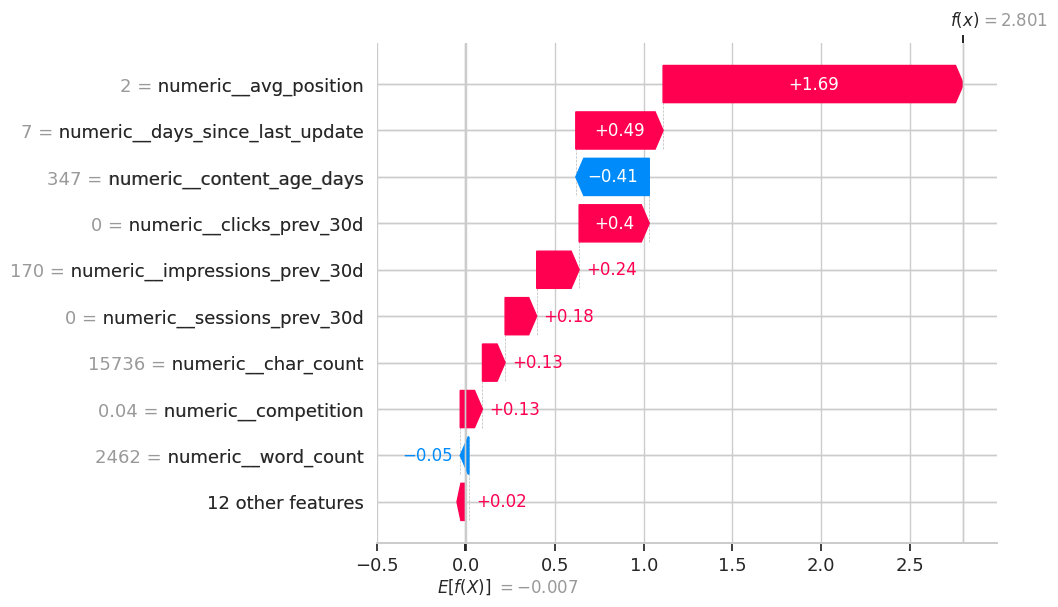

In [32]:
false_positive_positions = np.where(
    (y_proba >= 0.50) & (y_test.to_numpy() == 0)
)[0]

if len(false_positive_positions):
    fp_position = int(
        false_positive_positions[
            np.argmax(y_proba[false_positive_positions])
        ]
    )
    fp_explanation = explain_article(fp_position, top_n=10)
else:
    print("No false positives at threshold 0.50.")


## False Negative Inspection

ARTICLE-LEVEL DECLINE EXPLANATION
Test row             : 1909
Actual decline label : 1
Predicted risk       : 49.99%

Article features:


,value
search_volume,0.0
competition,0.0
cpc,0.0
word_count,NaN
char_count,NaN
impressions_prev_30d,2771
clicks_prev_30d,4
sessions_prev_30d,16
content_age_days,256
days_since_last_update,104



Top features increasing decline risk:


,feature,shap_value,direction
5,numeric__impressions_prev_30d,0.491811,increases decline risk
10,numeric__avg_position,0.221914,increases decline risk
0,numeric__search_volume,0.040901,increases decline risk
14,categorical__content_type_comparison article,0.008048,increases decline risk
16,categorical__content_type_keyword article,0.007002,increases decline risk
17,categorical__main_intent_commercial,0.000942,increases decline risk



Top features decreasing decline risk:


,feature,shap_value,direction
6,numeric__clicks_prev_30d,-0.276927,decreases decline risk
7,numeric__sessions_prev_30d,-0.142721,decreases decline risk
9,numeric__days_since_last_update,-0.079369,decreases decline risk
3,numeric__word_count,-0.077139,decreases decline risk
4,numeric__char_count,-0.058276,decreases decline risk
8,numeric__content_age_days,-0.056656,decreases decline risk
1,numeric__competition,-0.030964,decreases decline risk
2,numeric__cpc,-0.018182,decreases decline risk
18,categorical__main_intent_informational,-0.016549,decreases decline risk
20,categorical__main_intent_transactional,-0.002656,decreases decline risk


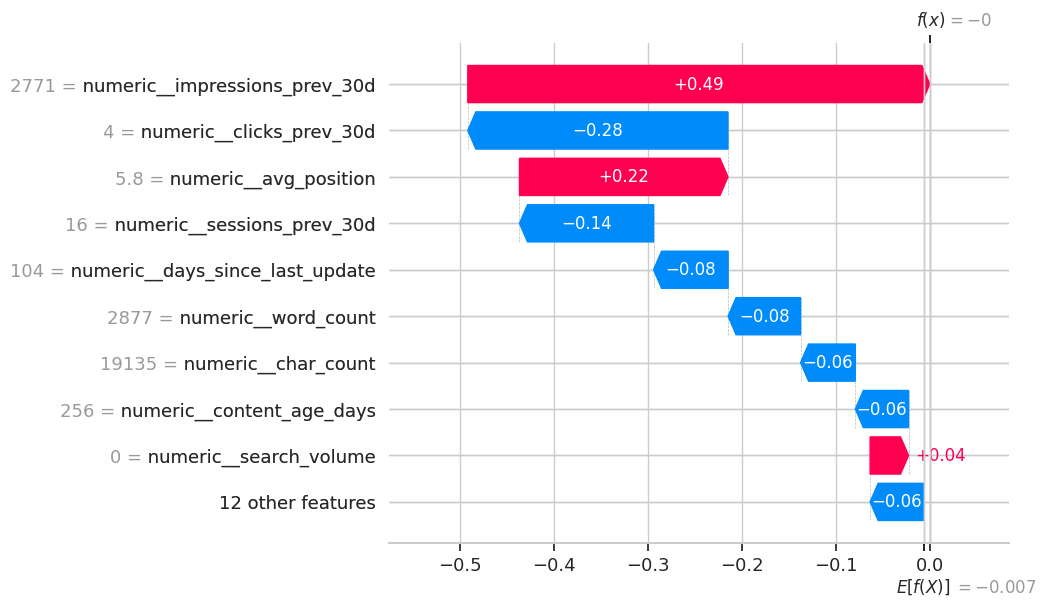

In [34]:
false_negative_positions = np.where(
    (y_proba < 0.50) & (y_test.to_numpy() == 1)
)[0]

if len(false_negative_positions):
    fn_position = int(
        false_negative_positions[
            np.argmax(y_proba[false_negative_positions])
        ]
    )
    fn_explanation = explain_article(fn_position, top_n=10)
else:
    print("No false negatives at threshold 0.50.")


## Operational Risk Report

In [36]:
risk_report = risk_table.copy()

risk_report["risk_level"] = pd.cut(
    risk_report["decline_probability"],
    bins=[-np.inf, 0.25, 0.50, 0.75, np.inf],
    labels=["LOW", "MEDIUM", "HIGH", "VERY HIGH"],
)

risk_report = risk_report.sort_values(
    "decline_probability",
    ascending=False
)

display(risk_report.head(30))

risk_report.to_csv(
    OUTPUT_DIR / "content_decline_risk_report.csv",
    index=False
)


,search_volume,competition,cpc,word_count,char_count,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,days_since_last_update,avg_position,competition_level,content_type,main_intent,actual_decline,decline_probability,predicted_decline,risk_level
3211,30.0,0.00,0.00,1604.0,10492.0,497,0,2,230,104,1.3,LOW,keyword article,informational,1,0.987324,1,VERY HIGH
3448,30.0,0.35,0.34,1410.0,9171.0,660,0,1,139,104,2.8,MEDIUM,keyword article,transactional,1,0.982441,1,VERY HIGH
9456,10.0,0.21,0.00,2947.0,20773.0,2,0,1,96,8,8.2,LOW,keyword article,commercial,1,0.980593,1,VERY HIGH
28243,NaN,NaN,NaN,4146.0,30889.0,13,0,0,92,8,7.3,NaN,feedly article,NaN,1,0.979208,1,VERY HIGH
2006,10.0,0.24,0.00,3033.0,20698.0,30,0,3,96,8,8.8,LOW,keyword article,informational,1,0.978609,1,VERY HIGH
24991,10.0,0.36,0.92,2947.0,20027.0,23,0,1,96,8,7.6,MEDIUM,keyword article,commercial,1,0.975211,1,VERY HIGH
15939,10.0,0.79,0.00,3224.0,22100.0,7,0,1,96,8,7.8,HIGH,keyword article,commercial,1,0.974159,1,VERY HIGH
11007,10.0,0.00,0.00,3138.0,20823.0,7,0,1,96,8,21.7,LOW,keyword article,commercial,1,0.972245,1,VERY HIGH
12444,0.0,0.00,0.00,4471.0,30867.0,10355,10,9,132,20,33.9,LOW,keyword article,informational,1,0.971965,1,VERY HIGH
16634,0.0,0.00,0.00,4153.0,27943.0,9761,0,3,141,20,31.5,LOW,keyword article,informational,1,0.971748,1,VERY HIGH


In [37]:
# Save the explainable model
MODEL_PATH = OUTPUT_DIR / "content_decline_xgboost_explainable.joblib"

joblib.dump(pipeline, MODEL_PATH)

print(f"Model saved: {MODEL_PATH}")
print("\nArtifacts:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(" -", p.name)


Model saved: outputs_content_decline/content_decline_xgboost_explainable.joblib

Artifacts:
 - content_decline_risk_report.csv
 - content_decline_risk_scores.csv
 - content_decline_xgboost_explainable.joblib
 - permutation_importance.csv
 - xgboost_feature_importance.csv
